Data Exploration

In [1]:
# Importing Necessary Libraries
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
import scipy.stats as stats
from datetime import datetime

In [2]:
# Data Set Overview

df = pd.read_csv('../data/raw/kc_house_data.csv')

df.head()
df.info()
df.describe()
df.shape
df.columns


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21613 entries, 0 to 21612
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             21613 non-null  int64  
 1   date           21613 non-null  object 
 2   price          21613 non-null  float64
 3   bedrooms       21613 non-null  int64  
 4   bathrooms      21613 non-null  float64
 5   sqft_living    21613 non-null  int64  
 6   sqft_lot       21613 non-null  int64  
 7   floors         21613 non-null  float64
 8   waterfront     21613 non-null  int64  
 9   view           21613 non-null  int64  
 10  condition      21613 non-null  int64  
 11  grade          21613 non-null  int64  
 12  sqft_above     21613 non-null  int64  
 13  sqft_basement  21613 non-null  int64  
 14  yr_built       21613 non-null  int64  
 15  yr_renovated   21613 non-null  int64  
 16  zipcode        21613 non-null  int64  
 17  lat            21613 non-null  float64
 18  long  

Index(['id', 'date', 'price', 'bedrooms', 'bathrooms', 'sqft_living',
       'sqft_lot', 'floors', 'waterfront', 'view', 'condition', 'grade',
       'sqft_above', 'sqft_basement', 'yr_built', 'yr_renovated', 'zipcode',
       'lat', 'long', 'sqft_living15', 'sqft_lot15'],
      dtype='object')

<Axes: >

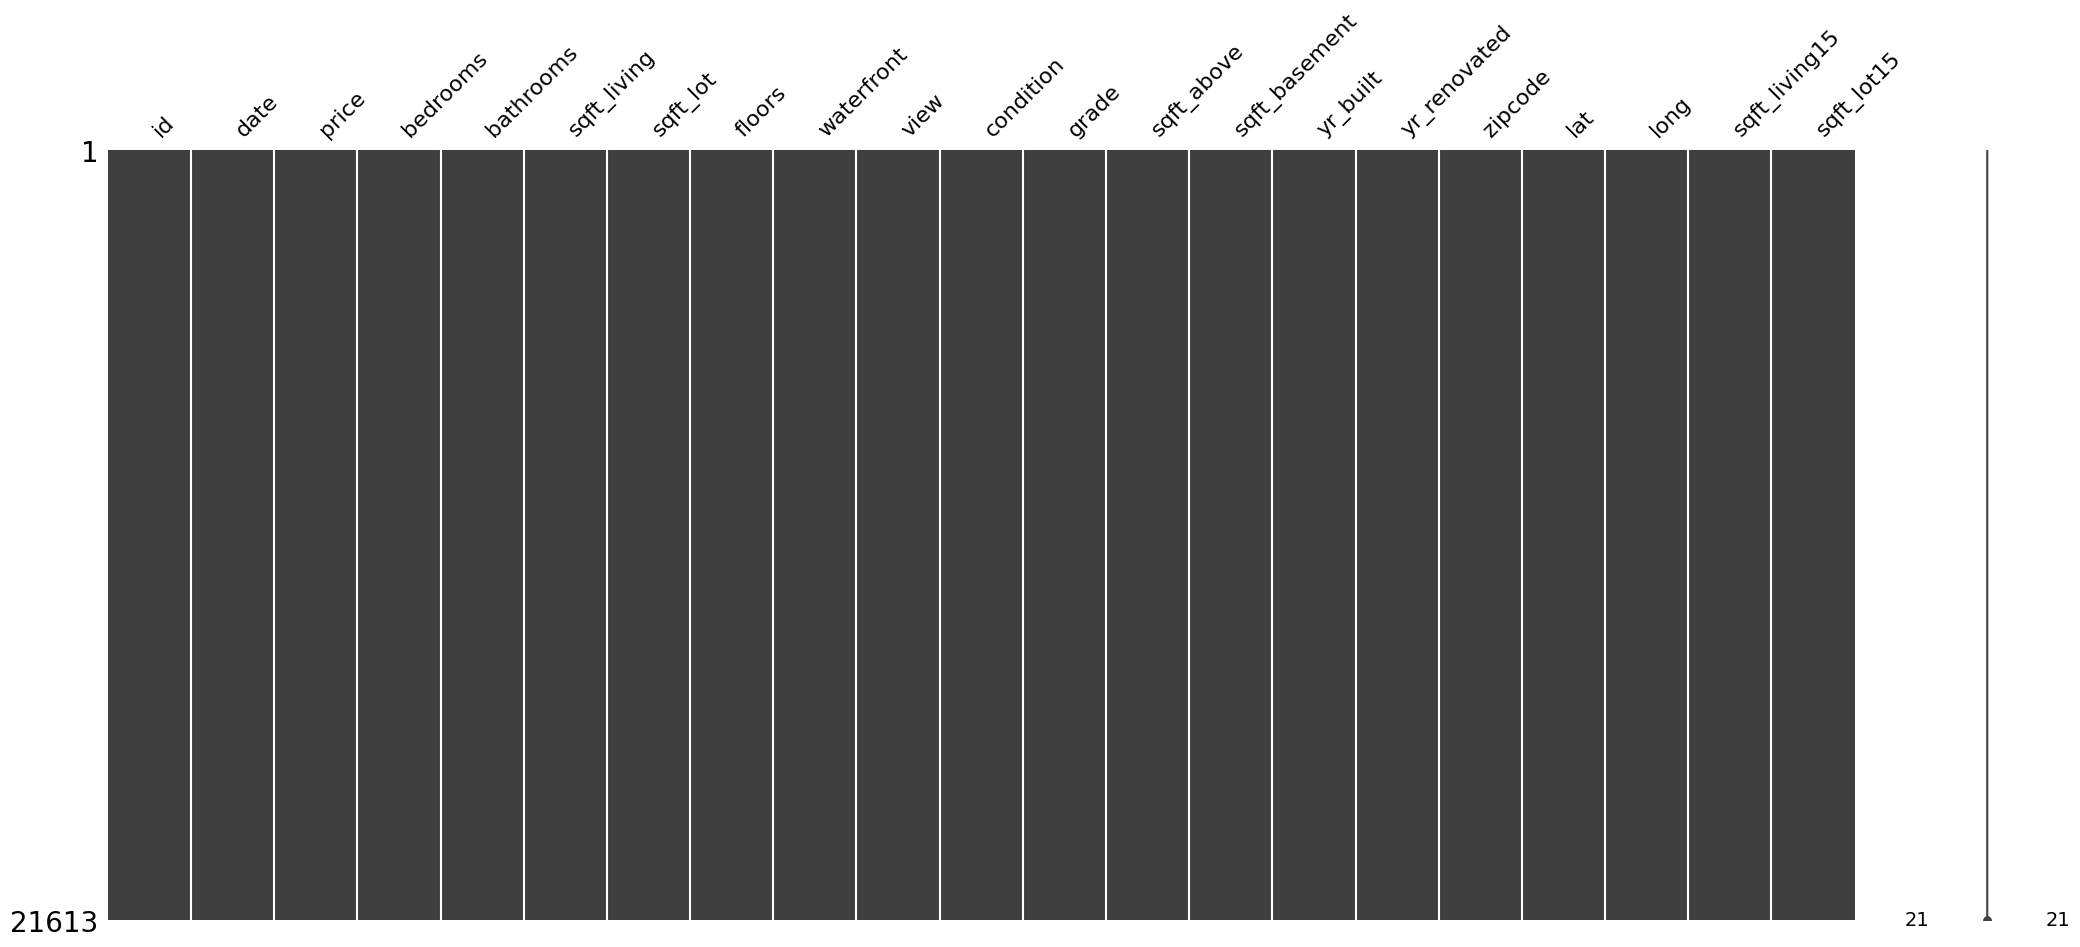

In [5]:
# Missing Values Check

df.isnull().sum()
df.isnull().mean() * 100

msno.matrix(df)

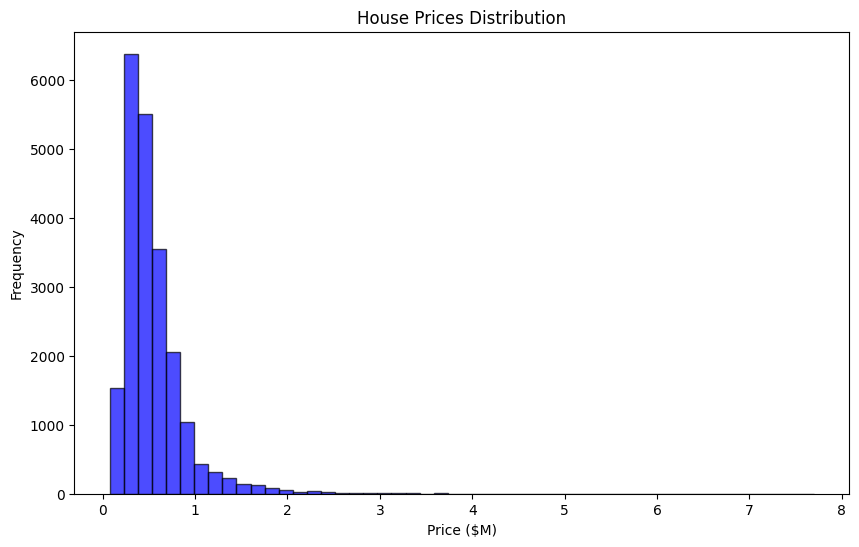

Mean Price: $540,088.14
Median Price: $450,000.00
Mode Price: $350,000.00
Price - Minimum: $75,000.00
Price - Maximum: $7,700,000.00
Price - Range: $7,625,000.00
Price - Standard Deviation: $367,127.20
Price - Skewness: 4.02
Lower Bound (1 SD): $172,960.95 and Upper Bound (1 SD): $907,215.34
Percentage of houses within 1 standard deviation: 88.90%


In [3]:
# Target Variable - Sale Price Analysis

plt.figure(figsize=(10, 6))
plt.hist(df['price']/1000000, bins=50, color='blue', edgecolor='black', alpha=0.7)
plt.title('House Prices Distribution')
plt.xlabel('Price ($M)')
plt.ylabel('Frequency')
plt.savefig('../output/figures/sale_price_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

df['price'].describe()
print(f'Mean Price: ${df['price'].mean():,.2f}')
print(f'Median Price: ${df['price'].median():,.2f}')
print(f'Mode Price: ${df['price'].mode()[0]:,.2f}')
print(f'Price - Minimum: ${df['price'].min():,.2f}')
print(f'Price - Maximum: ${df['price'].max():,.2f}')
print(f'Price - Range: ${df['price'].max() - df['price'].min():,.2f}')
print(f'Price - Standard Deviation: ${df['price'].std():,.2f}')
print(f'Price - Skewness: {df['price'].skew():.2f}')

mean_price = df['price'].mean()
std_price = df['price'].std()

lower_bound = mean_price - 1 * std_price
upper_bound = mean_price + 1 * std_price

within_1_std = df[(df['price'] >= lower_bound) & (df['price'] <= upper_bound)]
percentage_within_1_std = (len(within_1_std) / len(df)) * 100
print(f'Lower Bound (1 SD): ${lower_bound:,.2f} and Upper Bound (1 SD): ${upper_bound:,.2f}')
print(f'Percentage of houses within 1 standard deviation: {percentage_within_1_std:.2f}%')


###  Target Variable Analysis - What I found with data:

- Mean > Median > Mode & the plot distribution shows it is *right skewed*.  
- Standard Deviation:
    - Huge variation
    - Almost 89% within the 1 SD. So very few houses below $173K and Luxury houses above $907K forming a long right tail.
- Skewness:
    - Extremely right-skewed. Multi-million dollar houses are extreme outlier pulling ditribution. 


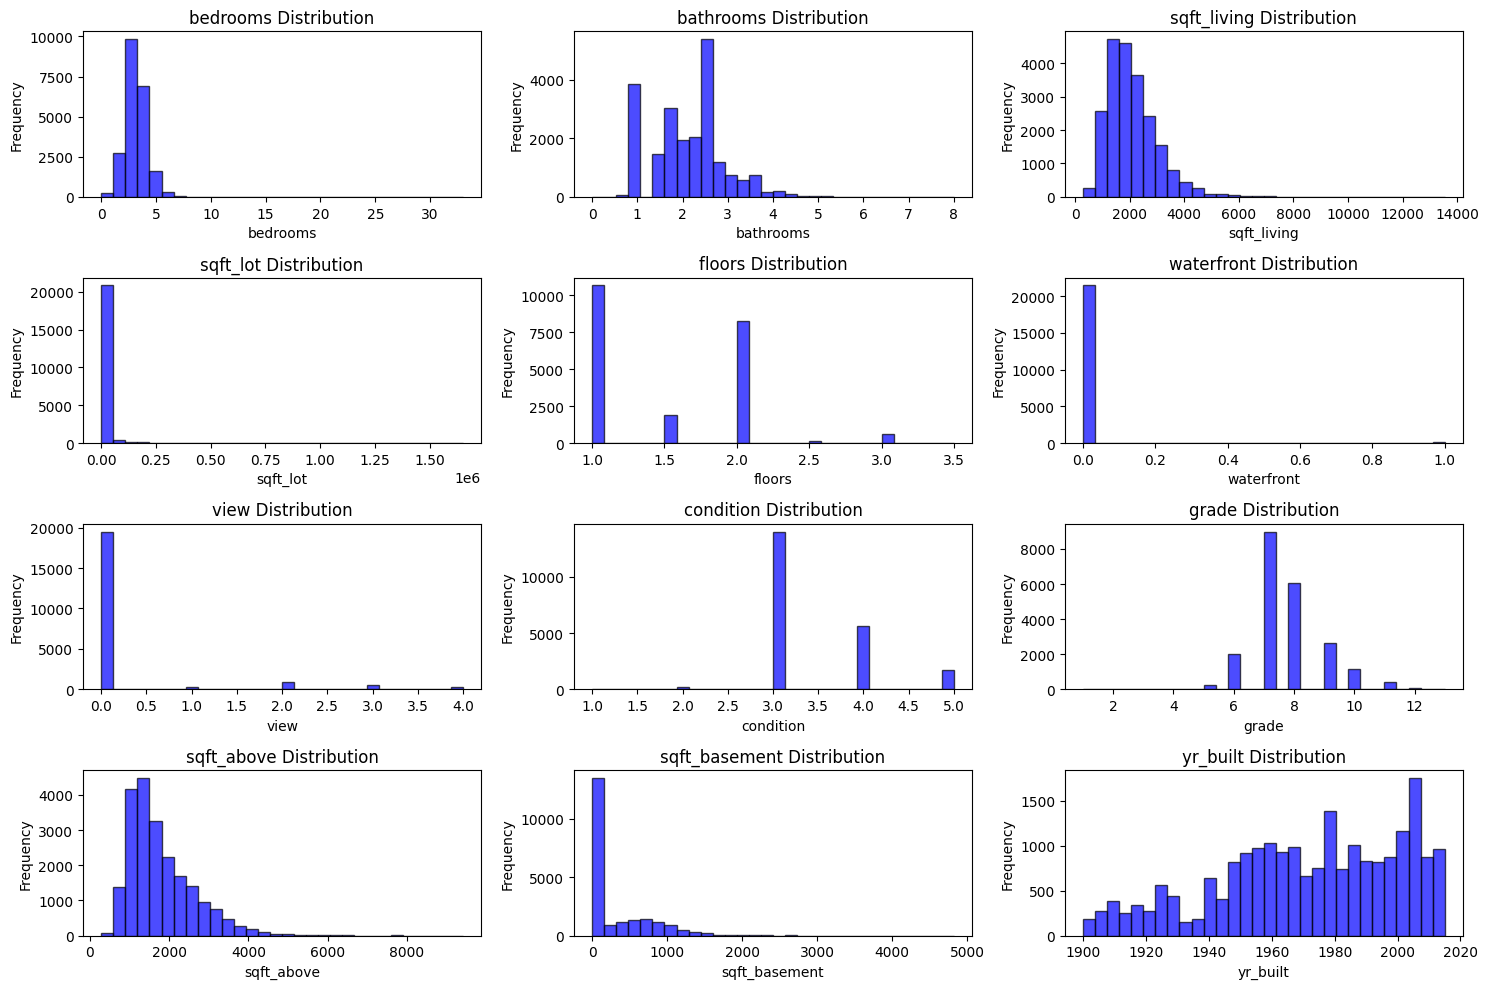

In [4]:
# Feature Distributions

features = ['bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors', 'waterfront', 'view', 'condition', 'grade', 'sqft_above', 'sqft_basement', 'yr_built']

fig, axes = plt.subplots(4, 3, figsize=(15, 10))
axes = axes.flatten()

for i, feature in enumerate(features):
    axes[i].hist(df[feature], bins=30, color='b', edgecolor='black', alpha=0.7)
    axes[i].set_title(f'{feature} Distribution')
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel('Frequency')

plt.tight_layout()
plt.savefig('../output/figures/feature_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

### Feature distribution Analysis

1. *Bedrooms*
    - 3 & 4 bedrooms are norm. 
    - Right skewed and fairly concentrated between 2 & 5. 

2. *Bathrooms*
    - Highest peak is 2.5 bathrooms.
    - 2 to 3 bathrooms are typical. 
    - Distribution fairly normal (slightly right skewed)

3. *Sqft Living:*
    - Right skewed 
    - Most homes between 1000 to 3000 sqft
    - Maybe Log transformation for this feature & maybe strong predictor of our target variable.

4. *Sqft Lot:*
    - Extremely right skewed
    - Most houses have between 5000 to 15000 sqft lot

5. *Floor Distribution*
    - Most homes are 1 floor or 2 floors. 
    - Can I treat it as Categorical?

6. *Year Built*
    - Fairly uniform distribution. 
    - Maybe need to create age feature: *Current year - yr_built*

Feature Correlations with Price:

Strong (r > 0.5):
  1. sqft_living: 0.7020
  2. grade: 0.6674
  3. sqft_above: 0.6056
  4. sqft_living15: 0.5854
  5. bathrooms: 0.5251

Moderate (0.3 < r <= 0.5):
  1. view: 0.3973
  2. sqft_basement: 0.3238
  3. bedrooms: 0.3083
  4. lat: 0.3070

Weak (r <= 0.3):
  1. waterfront: 0.2664
  2. floors: 0.2568
  3. yr_renovated: 0.1264
  4. sqft_lot: 0.0897
  5. sqft_lot15: 0.0824
  6. yr_built: 0.0540
  7. zipcode: -0.0532
  8. condition: 0.0364
  9. long: 0.0216


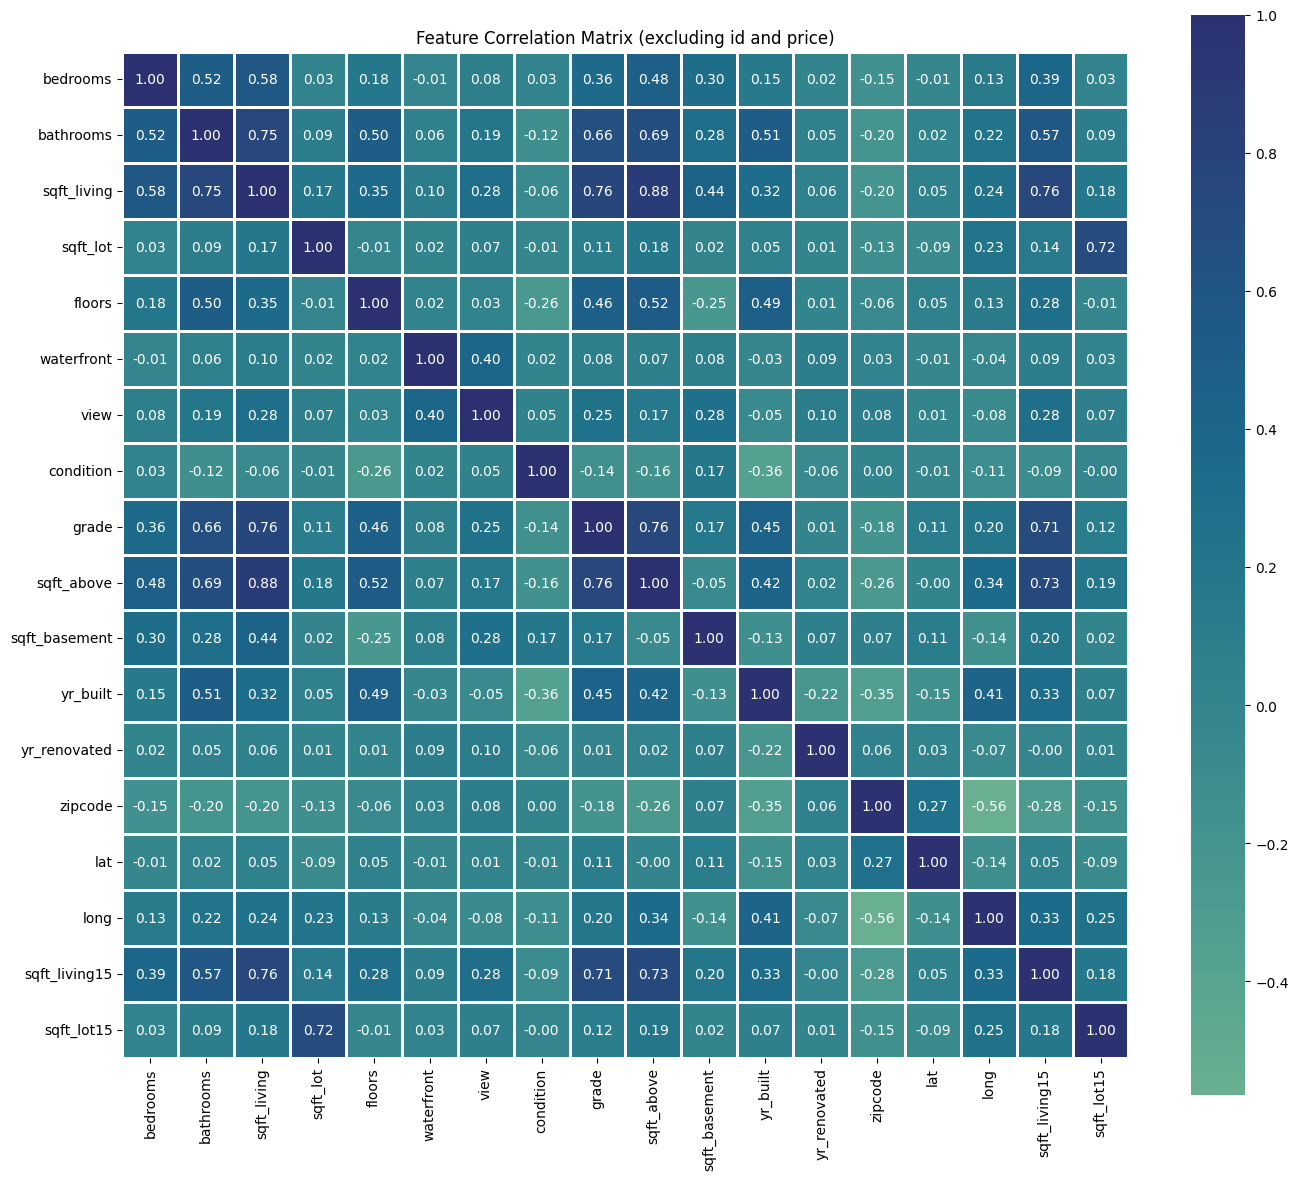

In [5]:
# Coorrelation Analysis

numeric_df = df.select_dtypes(include=[np.number])
numeric_df = numeric_df.drop(['id', 'price'], axis=1)

correlation = numeric_df.corrwith(df['price']).sort_values(ascending=False)



print("Feature Correlations with Price:")
cats = {
    'Strong (r > 0.5)': [],
    'Moderate (0.3 < r <= 0.5)': [],
    'Weak (r <= 0.3)': [],
}
for feature, corr_value in correlation.items():
    if feature in ['id', 'price']:
        continue
    absolute_corr = abs(corr_value)
    if absolute_corr > 0.5:
        cats['Strong (r > 0.5)'].append((feature, corr_value))
    elif 0.3 < absolute_corr <= 0.5:
        cats['Moderate (0.3 < r <= 0.5)'].append((feature, corr_value))
    else:
        cats['Weak (r <= 0.3)'].append((feature, corr_value))
for category, features in cats.items():
    print(f"\n{category}:")
    if features:
        features.sort(key=lambda x: abs(x[1]), reverse=True)
        for rank, (feature, corr_value) in enumerate(features, start=1):
            print(f"  {rank}. {feature}: {corr_value:.4f}")
    else:
        print("  None")

correlation_matrix = numeric_df.corr()

plt.figure(figsize=(14, 12))
sns.heatmap(correlation_matrix, annot=True, cmap='crest', center=0, fmt='.2f', 
            square=True, linewidths=1)
plt.title('Feature Correlation Matrix (excluding id and price)')
plt.tight_layout()
plt.savefig('../output/figures/feature_correlation.png', dpi=300, bbox_inches='tight')
plt.show()


### Correlation Analysis Notes

- Size & Grade (Quality) are top 2 drivers. 
- Bedrooms have weaker correlation compared to bathrooms. 
    - Possibly 3 Bed 3 Bath house > 4 bed 2 bath houses?...
- Year Built:
    - Might need house_age since no linear relationship. 


In [10]:
# Multi Collinearity Analysis

print("\nChecking multicollinearity:")
print(f"sqft_living ↔ sqft_above: {df[['sqft_living', 'sqft_above']].corr().iloc[0,1]:.3f}")
print(f"sqft_living ↔ bathrooms: {df[['sqft_living', 'bathrooms']].corr().iloc[0,1]:.3f}")
print(f"sqft_living15 ↔ sqft_living: {df[['sqft_living15', 'sqft_living']].corr().iloc[0,1]:.3f}")


Checking multicollinearity:
sqft_living ↔ sqft_above: 0.877
sqft_living ↔ bathrooms: 0.755
sqft_living15 ↔ sqft_living: 0.756


### Multi Collinearity Notes

- Need to drop *sqft_above* since model cannot distinguish their separation. Also, *sqft_living* = sqft_above + sqft_basement
- Regression coefficients become unstable. 
- Keeping only *sqft_living* since total space is better

9 features Plot: ['sqft_living', 'grade', 'sqft_above', 'sqft_living15', 'bathrooms', 'view', 'sqft_basement', 'bedrooms', 'lat']



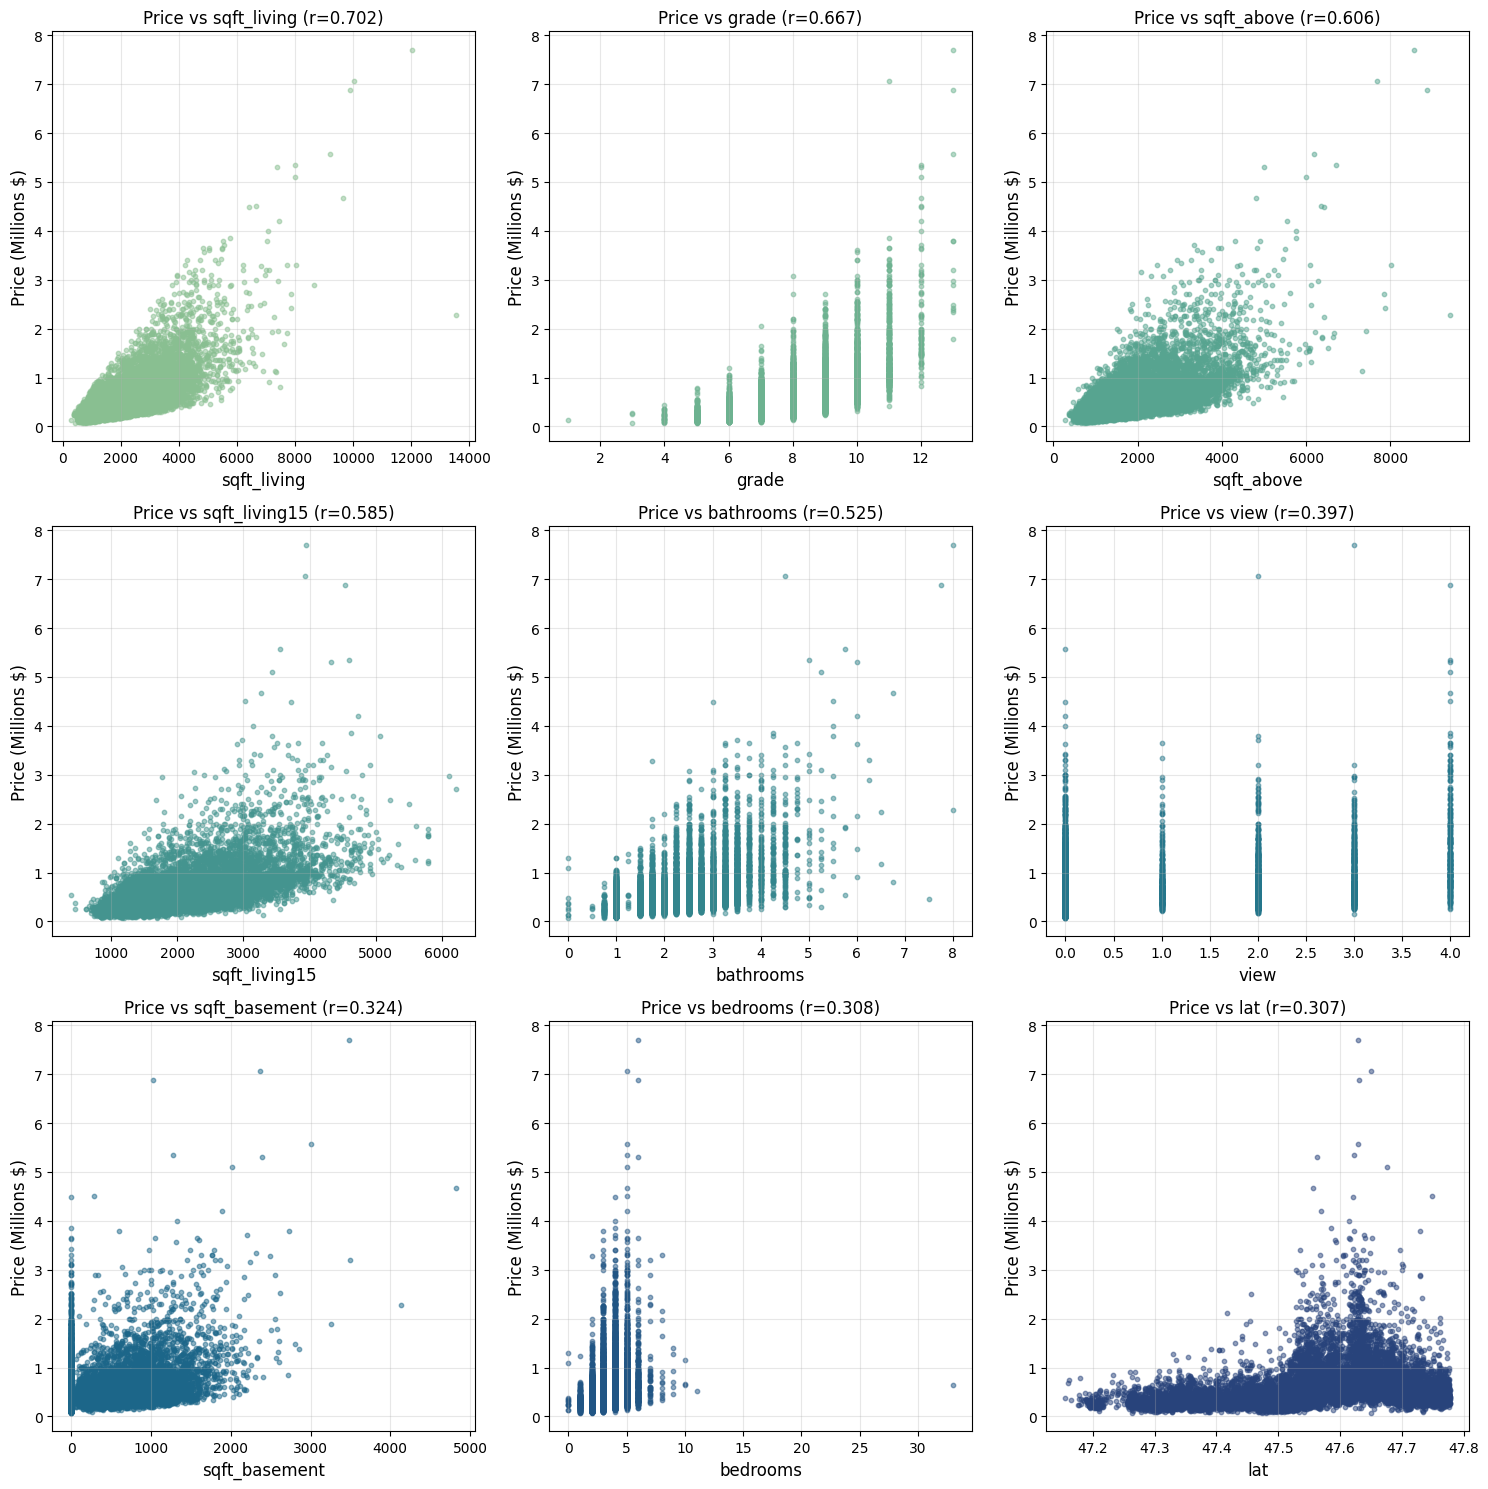

In [6]:
# Price vs Key Features (Strong & Moderate) Scatter Plots

strong_moderate_features = []

for feature, corr_value in correlation.items():
    if abs(corr_value) >= 0.3:
        strong_moderate_features.append((feature, corr_value))

strong_moderate_features.sort(key=lambda x: abs(x[1]), reverse=True)
features_to_plot = [f[0] for f in strong_moderate_features]

print(f"{len(features_to_plot)} features Plot: {features_to_plot}\n")

n_features = len(features_to_plot)
n_cols = 3
n_rows = (n_features + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5*n_rows))
axes = axes.flatten()

cmap = sns.color_palette('crest', n_colors=n_features)


for i, feature in enumerate(features_to_plot):
    axes[i].scatter(df[feature], df['price']/1000000, alpha=0.5, s=10, color=cmap[i])
    axes[i].set_xlabel(feature, fontsize=12)
    axes[i].set_ylabel('Price (Millions $)', fontsize=12)
    
    corr_val = correlation[feature]
    axes[i].set_title(f'Price vs {feature} (r={corr_val:.3f})', fontsize=12)
    axes[i].grid(True, alpha=0.3)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.savefig('../output/figures/price_vs_features.png', dpi=300, bbox_inches='tight')
plt.show()

Outlier Statistics:
Houses > $4M: 11
Houses > 8 bedrooms: 11
Houses > 9,000 sqft: 6


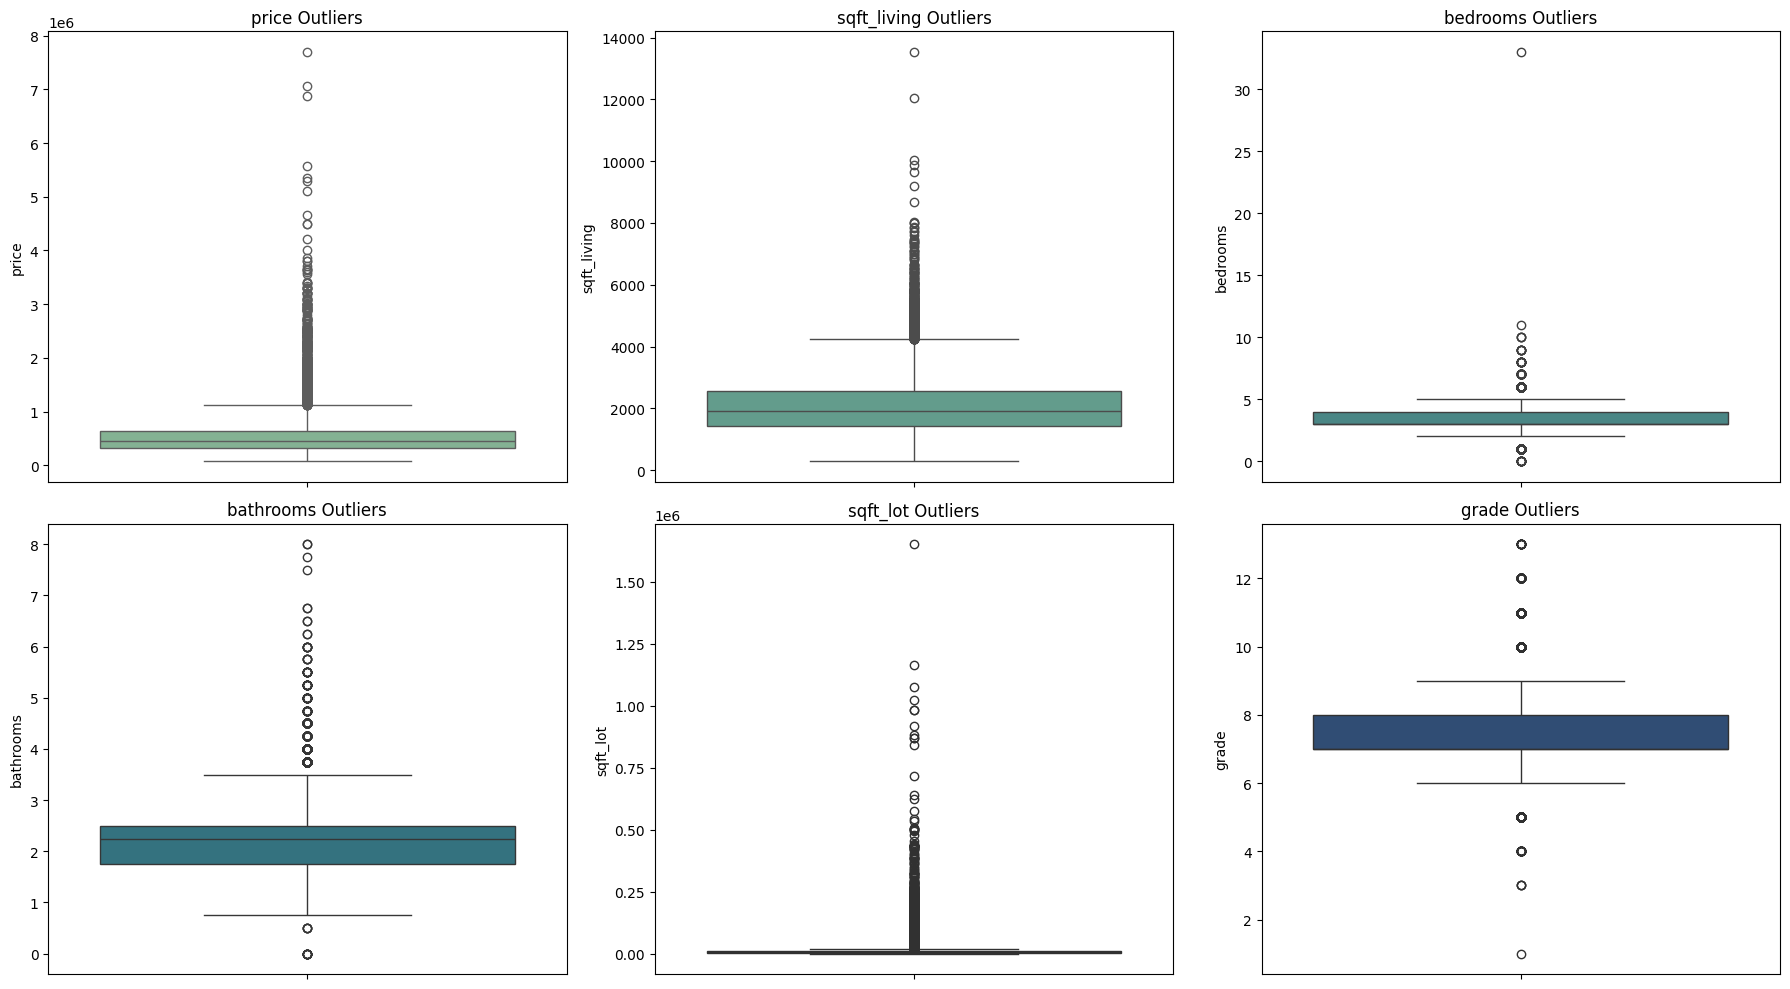


OUTLIER DETECTION (Z-Score Method, |z| > 3)
price               :   406 outliers ( 1.88%)
sqft_living         :   248 outliers ( 1.15%)
bedrooms            :    75 outliers ( 0.35%)
bathrooms           :   187 outliers ( 0.87%)
sqft_lot            :   347 outliers ( 1.61%)
grade               :   136 outliers ( 0.63%)


In [7]:
# Outlier Detection & Analysis

# Statistical outlier detection
print("Outlier Statistics:")
print(f"Houses > $4M: {len(df[df['price'] > 4000000])}")
print(f"Houses > 8 bedrooms: {len(df[df['bedrooms'] > 8])}")
print(f"Houses > 9,000 sqft: {len(df[df['sqft_living'] > 9000])}")


# Houses that are outliers in MULTIPLE features
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

features = ['price', 'sqft_living', 'bedrooms', 'bathrooms', 'sqft_lot', 'grade']
palette = sns.color_palette('crest', n_colors=6)

for i, feature in enumerate(features):
    sns.boxplot(y=df[feature], ax=axes[i], color=palette[i])
    axes[i].set_ylabel(feature)
    axes[i].set_title(f'{feature} Outliers')

plt.tight_layout()
plt.savefig('../output/figures/house_outliers.png', dpi=300, bbox_inches='tight')
plt.show()


# Detecting outliers using Z-score method

def detect_outliers_zscore(data, column, threshold=3):
    z_scores = np.abs(stats.zscore(data[column].dropna()))
    outliers = data[z_scores > threshold]
    return outliers

print("\n" + "=" * 50)
print("OUTLIER DETECTION (Z-Score Method, |z| > 3)")
print("=" * 50)

for feature in features:
    outliers_z = detect_outliers_zscore(df, feature)
    pct_z = (len(outliers_z) / len(df)) * 100
    print(f"{feature:20s}: {len(outliers_z):5d} outliers ({pct_z:5.2f}%)")



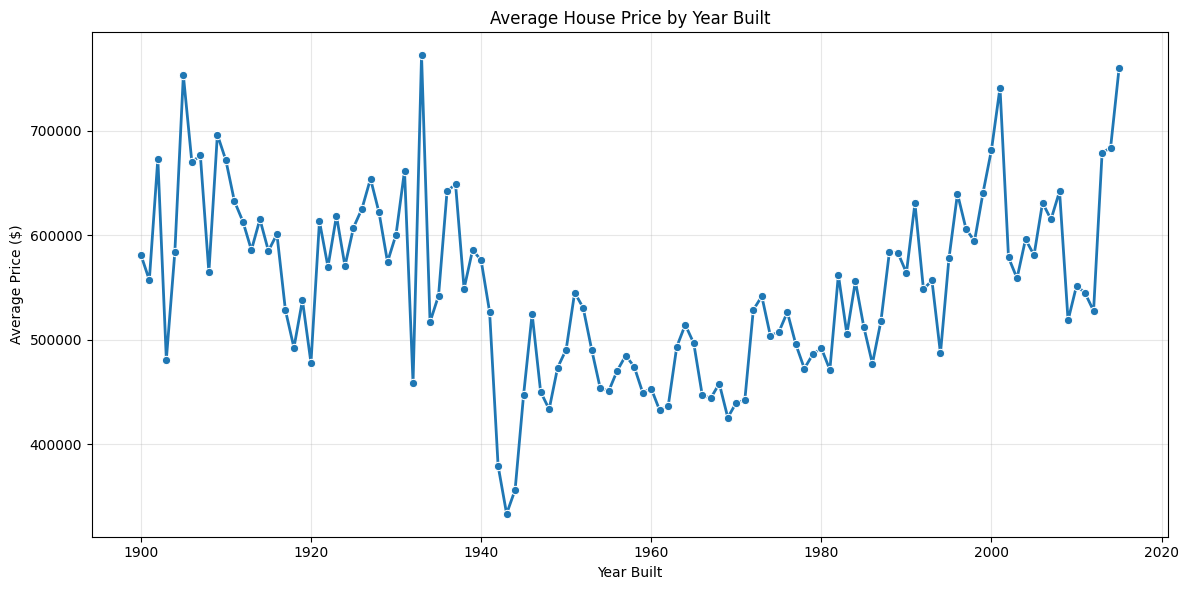


Year Built Statistics:
Oldest house: 1900
Newest house: 2015
Median year: 1975


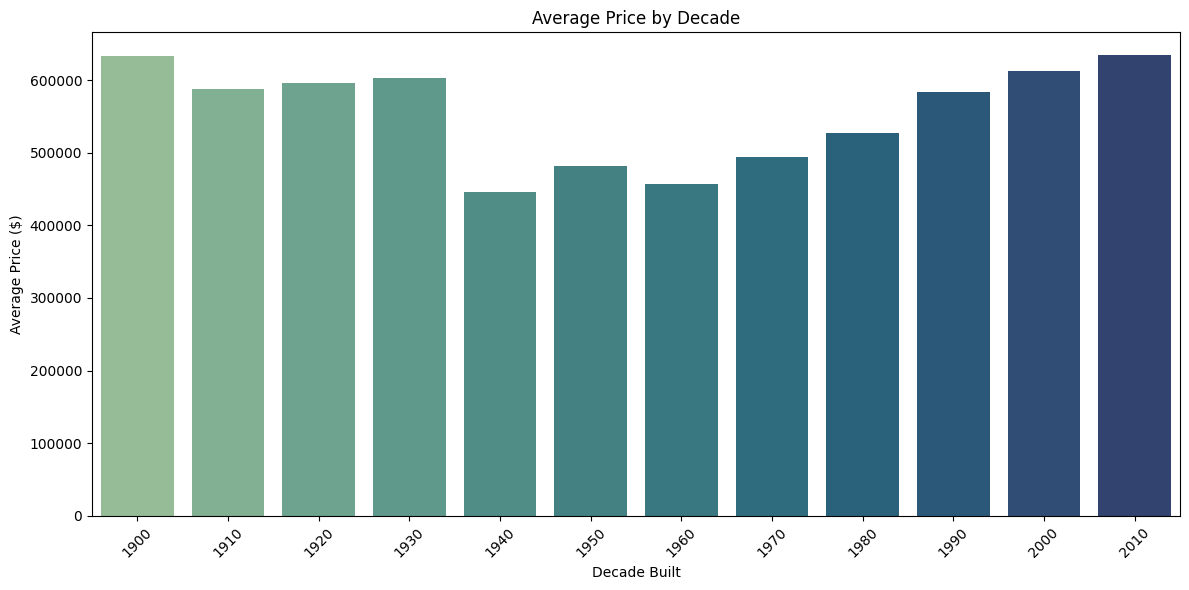

In [10]:
# Built Year Analysis

year_price = df.groupby('yr_built')['price'].mean()

plt.figure(figsize=(12, 6))
sns.lineplot(x=year_price.index, y=year_price.values, marker='o', linewidth=2)
plt.xlabel('Year Built')
plt.ylabel('Average Price ($)')
plt.title('Average House Price by Year Built')
plt.ticklabel_format(style='plain', axis='y')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../output/figures/house_price_by_year_built.png', dpi=300, bbox_inches='tight')
plt.show()

# Additional Year Built analysis
print("\nYear Built Statistics:")
print(f"Oldest house: {df['yr_built'].min()}")
print(f"Newest house: {df['yr_built'].max()}")
print(f"Median year: {int(df['yr_built'].median())}")

#Average Price by Decade
df['decade'] = (df['yr_built'] // 10) * 10
decade_price = df.groupby('decade')['price'].mean()
decade_df = decade_price.reset_index().rename(columns={'price': 'avg_price'})
plt.figure(figsize=(12, 6))
ax = sns.barplot(
    x='decade',
    y='avg_price',
    data=decade_df,
    hue=decade_df['decade'].astype(str),
    dodge=False,
    palette='crest',
    order=sorted(decade_df['decade'].unique())
)
if ax.get_legend() is not None:
    ax.get_legend().remove()
plt.xlabel('Decade Built')
plt.ylabel('Average Price ($)')
plt.title('Average Price by Decade')
plt.ticklabel_format(style='plain', axis='y')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('../output/figures/avg_price_by_decade.png', dpi=300, bbox_inches='tight')
plt.show()



In [ ]:
# Creating New House Age feature

current_year = datetime.now().year
df['house_age'] = current_year - df['yr_built']

print(df[['yr_built', 'house_age']].head())

print("\nHouse Age Statistics:")
print(df['house_age'].describe())

df.to_csv('../data/processed/kc_house_data_processed.csv', index=False)

   yr_built  house_age
0      1955         70
1      1951         74
2      1933         92
3      1965         60
4      1987         38

House Age Statistics:
count    21613.000000
mean        53.994864
std         29.373411
min         10.000000
25%         28.000000
50%         50.000000
75%         74.000000
max        125.000000
Name: house_age, dtype: float64


In [ ]:
# Data Quality Issues

# Unreasonably high bedroom counts (e.g., > 8 bedrooms)
high_bedroom_houses = df[df['bedrooms'] > 8][['bedrooms', 'price', 'sqft_living', 'bathrooms', 'grade', 'condition']]
print(f"\nHouses with > 8 bedrooms: {len(high_bedroom_houses)}")
print(high_bedroom_houses)


# price per sqft outliers

df['price_per_sqft'] = df['price'] / df['sqft_living']
expensive_houses = df.nlargest(10, 'price_per_sqft')[['price_per_sqft', 'price', 'sqft_living', 'bedrooms', 'bathrooms']]
print(f"\nTop 10 houses by price per sqft:")
print(expensive_houses)

# Unusually low-priced houses (e.g., < $100,000)
low_price = df[df['price'] < 100000][['price', 'bedrooms', 'bathrooms', 
                                       'sqft_living', 'condition', 'yr_built']]
print(f"\nHouses with price < $100,000: {len(low_price)}")
print(low_price)


Houses with > 8 bedrooms: 11
       bedrooms      price  sqft_living  bathrooms  grade  condition
4096          9   599999.0         3830       4.50      7          3
4235          9   700000.0         3680       3.00      7          3
6079          9  1280000.0         3650       4.50      8          3
8546          9   450000.0         4050       7.50      7          3
8757         11   520000.0         3000       3.00      7          3
13314        10  1148000.0         4590       5.25      9          3
15161        10   650000.0         3610       2.00      7          4
15870        33   640000.0         1620       1.75      7          5
16844         9  1400000.0         4620       4.00     11          3
18443         9   934000.0         2820       3.00      7          3
19254        10   660000.0         2920       3.00      7          4

Top 10 houses by price per sqft:
       price_per_sqft      price  sqft_living  bedrooms  bathrooms
19336      810.138889   874950.0         

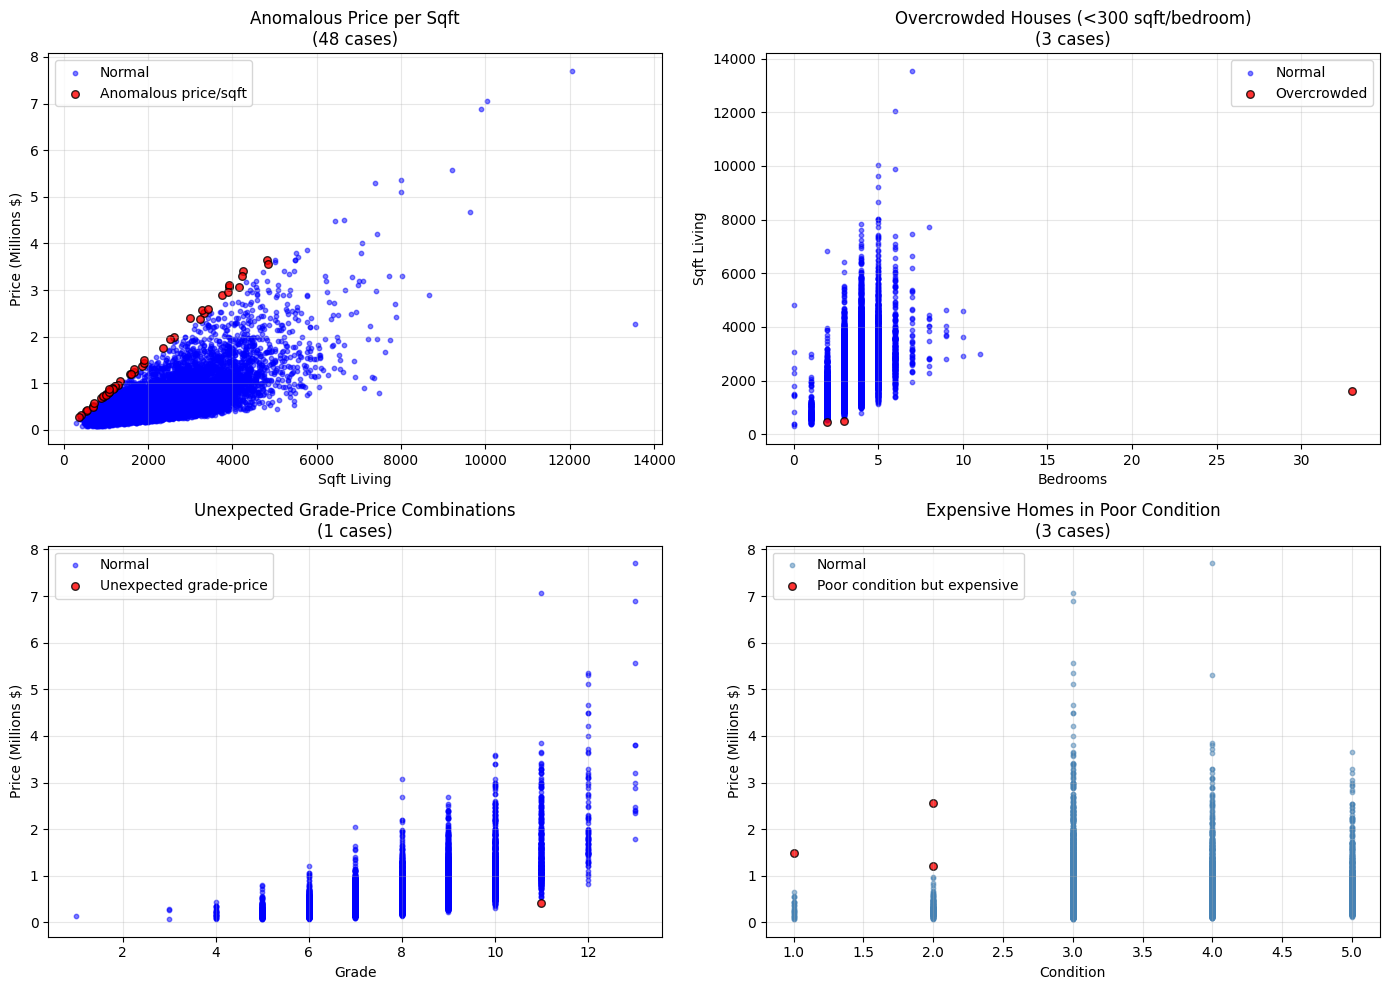

In [11]:
# Identify TRULY anomalous points in key feature relationships
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

# 1. Price per sqft vs sqft_living (Underpriced vs Overpriced)
df['price_per_sqft'] = df['price'] / df['sqft_living']
median_price_per_sqft = df['price_per_sqft'].median()

# Extreme price per sqft (>3x or <0.3x median)
extreme_price_per_sqft = (df['price_per_sqft'] > 3*median_price_per_sqft) | \
                         (df['price_per_sqft'] < 0.3*median_price_per_sqft)

axes[0].scatter(df.loc[~extreme_price_per_sqft, 'sqft_living'], 
               df.loc[~extreme_price_per_sqft, 'price']/1000000, 
               alpha=0.5, s=10, label='Normal', color='blue')
axes[0].scatter(df.loc[extreme_price_per_sqft, 'sqft_living'], 
               df.loc[extreme_price_per_sqft, 'price']/1000000, 
               alpha=0.8, s=30, label='Anomalous price/sqft', color='red', edgecolors='black')
axes[0].set_xlabel('Sqft Living')
axes[0].set_ylabel('Price (Millions $)')
axes[0].set_title(f'Anomalous Price per Sqft\n({extreme_price_per_sqft.sum()} cases)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# 2. Bedrooms vs sqft_living (Overcrowded)
df['sqft_per_bedroom'] = df['sqft_living'] / (df['bedrooms'] + 1)
overcrowded = df['sqft_per_bedroom'] < 150 

axes[1].scatter(df.loc[~overcrowded, 'bedrooms'], 
               df.loc[~overcrowded, 'sqft_living'], 
               alpha=0.5, s=10, label='Normal', color='blue')
axes[1].scatter(df.loc[overcrowded, 'bedrooms'], 
               df.loc[overcrowded, 'sqft_living'], 
               alpha=0.8, s=30, label='Overcrowded', color='red', edgecolors='black')
axes[1].set_xlabel('Bedrooms')
axes[1].set_ylabel('Sqft Living')
axes[1].set_title(f'Overcrowded Houses (<300 sqft/bedroom)\n({overcrowded.sum()} cases)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# 3. Grade vs price (To find undervalued high-grade or overvalued low-grade)
# Expectation/Assumption: grade 12-13 should be >$1M, grade 3-5 should be <$500K
anomalous_grade = ((df['grade'] >= 11) & (df['price'] < 500000)) | \
                  ((df['grade'] <= 5) & (df['price'] > 1500000))

axes[2].scatter(df.loc[~anomalous_grade, 'grade'], 
               df.loc[~anomalous_grade, 'price']/1000000, 
               alpha=0.5, s=10, label='Normal', color='blue')
axes[2].scatter(df.loc[anomalous_grade, 'grade'], 
               df.loc[anomalous_grade, 'price']/1000000, 
               alpha=0.8, s=30, label='Unexpected grade-price', color='red', edgecolors='black')
axes[2].set_xlabel('Grade')
axes[2].set_ylabel('Price (Millions $)')
axes[2].set_title(f'Unexpected Grade-Price Combinations\n({anomalous_grade.sum()} cases)')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

# 4. Condition vs price
poor_condition_expensive = (df['condition'] <= 2) & (df['price'] > 1000000)

axes[3].scatter(df.loc[~poor_condition_expensive, 'condition'], 
               df.loc[~poor_condition_expensive, 'price']/1000000, 
               alpha=0.5, s=10, label='Normal', color='steelblue')
axes[3].scatter(df.loc[poor_condition_expensive, 'condition'], 
               df.loc[poor_condition_expensive, 'price']/1000000, 
               alpha=0.8, s=30, label='Poor condition but expensive', color='red', edgecolors='black')
axes[3].set_xlabel('Condition')
axes[3].set_ylabel('Price (Millions $)')
axes[3].set_title(f'Expensive Homes in Poor Condition\n({poor_condition_expensive.sum()} cases)')
axes[3].legend()
axes[3].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../output/figures/anomaly_price_overcrowded_expensive.png', dpi=300, bbox_inches='tight')
plt.show()